# Per-user Blacklight coverage

For each panelist, compute the share of their visits that land on a domain successfully scanned by Blacklight. Plot the CDF.

In [1]:
import sys
sys.path.insert(0, '/home/lsys/private_blacklight/scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from constants import filepaths
from utilities import load_visit_data, save_mpl_fig

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.3)

Checking that all paths exist:
{'web_mobile': True, 'web_desktop': True, 'web': True, 'yg_profile': True, 'blacklight': True, 'who': True}


## Load data

In [2]:
df_blacklight = pd.read_csv(filepaths['blacklight'])
df_blacklight['private_domain'] = df_blacklight['filename'].str.replace('_', '.', regex=False)
scanned_domains = set(df_blacklight['private_domain'])
print(f'Successfully scanned domains: {len(scanned_domains):,}')

Successfully scanned domains: 34,078


In [3]:
df_visits = load_visit_data()
print(f'Total visits: {len(df_visits):,}')
print(f'Unique panelists with any visit: {df_visits["caseid"].nunique():,}')

len(df_visits)=6,297,382
Total visits: 6,297,382
Unique panelists with any visit: 1,135


## Compute per-user coverage

Drop visits with no `private_domain`, then for each user compute (visits to scanned domain) / (total visits).

In [4]:
df = df_visits.dropna(subset=['private_domain']).copy()
df['scanned'] = df['private_domain'].isin(scanned_domains)

per_user = (
    df.groupby('caseid')
      .agg(total_visits=('private_domain', 'size'),
           scanned_visits=('scanned', 'sum'))
      .assign(coverage=lambda d: d['scanned_visits'] / d['total_visits'])
)
per_user.head()

,total_visits,scanned_visits,coverage
caseid,,,
47541,17194,15180,0.882866
56565,11479,9309,0.810959
203271,6540,4998,0.764220
216457,1770,1469,0.829944
257495,10012,7306,0.729724


In [5]:
print(per_user['coverage'].describe(percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).round(3))
print()
print(f'Panel-wide pooled coverage: {df["scanned"].sum() / len(df):.1%}')
print(f'Mean of per-user coverage:  {per_user["coverage"].mean():.1%}')
print(f'Median per-user coverage:   {per_user["coverage"].median():.1%}')

count    1134.000
mean        0.742
std         0.149
min         0.000
5%          0.463
10%         0.538
25%         0.663
50%         0.766
75%         0.844
90%         0.905
95%         0.944
max         1.000
Name: coverage, dtype: float64

Panel-wide pooled coverage: 76.4%
Mean of per-user coverage:  74.2%
Median per-user coverage:   76.6%


## CDF

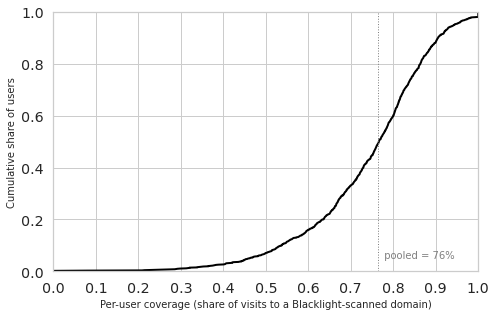

In [ ]:
x = np.sort(per_user['coverage'].values)
y = np.arange(1, len(x) + 1) / len(x)

_, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, y, color='black', linewidth=2)

# Reference line at panel-wide 76%
pooled = df['scanned'].sum() / len(df)
ax.axvline(pooled, color='gray', linestyle=':', linewidth=1)
ax.text(pooled, 0.05, f'  pooled = {pooled:.0%}', color='gray', fontsize=10)

ax.set_xlabel('Per-user coverage (share of visits to a Blacklight-scanned domain)')
ax.set_ylabel('Cumulative share of users')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(0, 1.01, 0.1))

plt.tight_layout()

In [ ]:
for thresh in [0.5, 0.6, 0.7, 0.8, 0.9]:
    share = (per_user['coverage'] >= thresh).mean()
    print(f'{share:.1%} of users have >= {thresh:.0%} coverage')

92.9% of users have >= 50% coverage
84.0% of users have >= 60% coverage
67.0% of users have >= 70% coverage
40.2% of users have >= 80% coverage
11.7% of users have >= 90% coverage
